# PolyAtlas — Notebook 05f: Feature-Climbing Forward Selection on NbBench

**Project:** Cross-Campaign Polyreactivity Atlas  
**Notebook:** `PolyAtlas_05f_feature_climb`  
**Version:** `v0.1.0`  
**Date:** 2026-04-21

## Purpose

Notebook 05e showed that zero-training CDR-H3 charge achieves AUROC 0.7262 on NbBench PolyRx test (n=24,955), ranking below all 11 language models (0.815-0.842). This notebook asks: how much of the LM performance can we recover with a ranked set of hand-crafted physicochemical features?

## Approach

Greedy forward feature selection:
1. Build a comprehensive catalog of ~40-50 physicochemical features across CDR-H1, CDR-H2, CDR-H3, and full variable region.
2. Starting with charge alone, at each step try adding every remaining feature one at a time, fit LR on train (n=101,673), evaluate on validation (n=14,529), and pick the feature that most improves validation AUROC.
3. Continue until AUROC gain per feature drops below 0.002 or 25 features reached.
4. Report final model performance on test (n=24,955) with bootstrap 95% CI.
5. Compare final AUROC to NbBench's 11 language models.

## Validation vs test protocol

Feature selection uses validation AUROC to avoid overfitting to test. Final evaluation uses test AUROC only once, at the end. This is the standard clean protocol for this kind of study.

## Runtime

~10-15 minutes. Forward selection is the heaviest step, ~40 candidate features × ~20 steps × LR fit per step.

In [ ]:
from IPython.display import display, Javascript
display(Javascript('''
function ClickConnect(){
    const selectors = ["#top-toolbar > colab-connect-button", "colab-connect-button", "#connect"];
    for (const sel of selectors) {
        const el = document.querySelector(sel);
        if (el) { if (el.shadowRoot) { const inner = el.shadowRoot.querySelector("#connect"); if (inner) { inner.click(); return; } } el.click(); return; }
    }
}
setInterval(ClickConnect, 60000);
'''))

from google.colab import drive
from pathlib import Path
import json

drive.mount('/content/drive', force_remount=True)

DRIVE_ROOT = Path('/content/drive/MyDrive/PolyAtlas')
NOTEBOOK_NAME = "PolyAtlas_05f_feature_climb"
PROJECT_VERSION = "0.1.0"
DRIVE_OUTPUT = DRIVE_ROOT / f"{NOTEBOOK_NAME}_v{PROJECT_VERSION}"
DRIVE_OUTPUT.mkdir(parents=True, exist_ok=True)
print(f"Output dir: {DRIVE_OUTPUT}")

<IPython.core.display.Javascript object>

Mounted at /content/drive
Output dir: /content/drive/MyDrive/PolyAtlas/PolyAtlas_05f_feature_climb_v0.1.0


In [ ]:
!pip install -q datasets scikit-learn

In [ ]:
import pandas as pd
import numpy as np
from datasets import load_dataset
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

ds = load_dataset('ZYMScott/polyreaction')
train_df = ds['train'].to_pandas()
val_df = ds['validation'].to_pandas()
test_df = ds['test'].to_pandas()

print(f"Train: {train_df.shape}, Val: {val_df.shape}, Test: {test_df.shape}")

README.md: 0.00B [00:00, ?B/s]

train.csv:   0%|          | 0.00/16.0M [00:00<?, ?B/s]

val.csv: 0.00B [00:00, ?B/s]

test.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/101854 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/14613 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25007 [00:00<?, ? examples/s]

Train: (101854, 5), Val: (14613, 5), Test: (25007, 5)


## §1. Feature catalog

Build hand-crafted features across CDR-H1, CDR-H2, CDR-H3, and full VHH sequence:

**Per-region features (repeated for CDR1, CDR2, CDR3, full):**
- Length
- Net charge at pH 7.4 (K+R minus D+E)
- Absolute charge |net charge|
- Fraction positive (K+R)
- Fraction negative (D+E)
- Mean Kyte-Doolittle hydrophobicity
- Fraction aromatic (FWY)
- Tryptophan fraction (W)
- Arginine fraction (R) — Boughter 2020 specifically flagged
- Valine fraction (V) — Boughter feature
- Glycine fraction (G) — flexibility
- Fraction hydrophobic (ILVFMWYC)

**Special features:**
- CDR-H3 charge dipole (N-term half charge minus C-term half charge)
- Maximum hydrophobic run in CDR-H3
- Predicted isoelectric point of CDR-H3 and full seq (simple approximation)

In [ ]:
KYTE_DOOLITTLE = {'A': 1.8,'C': 2.5,'D':-3.5,'E':-3.5,'F': 2.8,'G':-0.4,'H':-3.2,'I': 4.5,'K':-3.9,
                   'L': 3.8,'M': 1.9,'N':-3.5,'P':-1.6,'Q':-3.5,'R':-4.5,'S':-0.8,'T':-0.7,'V': 4.2,
                   'W':-0.9,'Y':-1.3}
CHARGE_AT_PH74 = {'D':-1,'E':-1,'K':+1,'R':+1,'H':+0.1}
AROMATIC = set('FWY')
POSITIVE = set('KR')
NEGATIVE = set('DE')
HYDROPHOBIC = set('ILVFMWYC')

# Approximate pKa values for simple pI estimation (Bjellqvist-simplified)
PKA = {'C_term': 3.55, 'D': 4.05, 'E': 4.45, 'H': 5.98, 'K': 10.0, 'R': 12.0, 'Y': 10.0, 'C': 9.0, 'N_term': 8.0}

def net_charge(seq):
    if not isinstance(seq, str) or len(seq) == 0: return np.nan
    return sum(CHARGE_AT_PH74.get(a, 0) for a in seq.upper())

def frac(seq, subset):
    if not isinstance(seq, str) or len(seq) == 0: return np.nan
    s = seq.upper()
    return sum(1 for a in s if a in subset) / len(s)

def frac_residue(seq, residue):
    if not isinstance(seq, str) or len(seq) == 0: return np.nan
    return seq.upper().count(residue) / len(seq)

def mean_hydrophobicity(seq):
    if not isinstance(seq, str) or len(seq) == 0: return np.nan
    return np.mean([KYTE_DOOLITTLE.get(a, 0) for a in seq.upper()])

def max_hydrophobic_run(seq):
    if not isinstance(seq, str) or len(seq) == 0: return 0
    s = seq.upper()
    best, cur = 0, 0
    for a in s:
        if a in HYDROPHOBIC:
            cur += 1
            best = max(best, cur)
        else:
            cur = 0
    return best

def charge_dipole(seq):
    """Charge at N-terminal half minus C-terminal half (asymmetry)."""
    if not isinstance(seq, str) or len(seq) < 4: return 0
    mid = len(seq) // 2
    nterm_charge = net_charge(seq[:mid])
    cterm_charge = net_charge(seq[mid:])
    return nterm_charge - cterm_charge

def estimate_pI(seq):
    """Crude isoelectric point via bisection on net charge vs pH."""
    if not isinstance(seq, str) or len(seq) == 0: return np.nan
    s = seq.upper()
    def charge_at_ph(ph):
        c = 0
        # N-term
        c += 1 / (1 + 10**(ph - PKA['N_term']))
        # C-term
        c -= 1 / (1 + 10**(PKA['C_term'] - ph))
        for a in s:
            if a in ('K', 'R'):
                c += 1 / (1 + 10**(ph - PKA[a]))
            elif a in ('D', 'E'):
                c -= 1 / (1 + 10**(PKA[a] - ph))
            elif a == 'H':
                c += 1 / (1 + 10**(ph - PKA['H']))
            elif a == 'Y':
                c -= 1 / (1 + 10**(PKA['Y'] - ph))
            elif a == 'C':
                c -= 1 / (1 + 10**(PKA['C'] - ph))
        return c
    lo, hi = 0.0, 14.0
    for _ in range(50):
        mid = (lo + hi) / 2
        if charge_at_ph(mid) > 0:
            lo = mid
        else:
            hi = mid
    return (lo + hi) / 2

def build_features(df):
    feats = pd.DataFrame(index=df.index)
    for region, col in [('H1', 'CDR1_nogaps'), ('H2', 'CDR2_nogaps'),
                          ('H3', 'CDR3_nogaps'), ('full', 'seq')]:
        seqs = df[col].fillna('').astype(str)
        feats[f'{region}_len']       = seqs.str.len()
        feats[f'{region}_charge']    = seqs.apply(net_charge)
        feats[f'{region}_abs_charge'] = feats[f'{region}_charge'].abs()
        feats[f'{region}_pos_frac']  = seqs.apply(lambda s: frac(s, POSITIVE))
        feats[f'{region}_neg_frac']  = seqs.apply(lambda s: frac(s, NEGATIVE))
        feats[f'{region}_hphob']     = seqs.apply(mean_hydrophobicity)
        feats[f'{region}_hphob_frac'] = seqs.apply(lambda s: frac(s, HYDROPHOBIC))
        feats[f'{region}_arom']      = seqs.apply(lambda s: frac(s, AROMATIC))
        feats[f'{region}_W']         = seqs.apply(lambda s: frac_residue(s, 'W'))
        feats[f'{region}_R']         = seqs.apply(lambda s: frac_residue(s, 'R'))
        feats[f'{region}_V']         = seqs.apply(lambda s: frac_residue(s, 'V'))
        feats[f'{region}_G']         = seqs.apply(lambda s: frac_residue(s, 'G'))
    # Special features
    feats['H3_charge_dipole']     = df['CDR3_nogaps'].fillna('').astype(str).apply(charge_dipole)
    feats['H3_max_hphob_run']     = df['CDR3_nogaps'].fillna('').astype(str).apply(max_hydrophobic_run)
    feats['H3_pI']                = df['CDR3_nogaps'].fillna('').astype(str).apply(estimate_pI)
    feats['full_pI']              = df['seq'].fillna('').astype(str).apply(estimate_pI)
    return feats.fillna(0)

print("Computing features on train...")
X_train_full = build_features(train_df)
print("Computing features on val...")
X_val_full = build_features(val_df)
print("Computing features on test...")
X_test_full = build_features(test_df)

y_train = train_df['label'].astype(int).values
y_val = val_df['label'].astype(int).values
y_test = test_df['label'].astype(int).values

# Drop rows with empty CDR-H3 (they'll have len=0 which is already a feature; but we still want valid label)
# For consistency with 05e, drop rows where CDR3_nogaps is missing.
train_keep = X_train_full['H3_len'] > 0
val_keep = X_val_full['H3_len'] > 0
test_keep = X_test_full['H3_len'] > 0

X_train_full = X_train_full[train_keep].reset_index(drop=True)
y_train = y_train[train_keep.values]
X_val_full = X_val_full[val_keep].reset_index(drop=True)
y_val = y_val[val_keep.values]
X_test_full = X_test_full[test_keep].reset_index(drop=True)
y_test = y_test[test_keep.values]

print()
print(f"After cleaning: train n={len(X_train_full)}, val n={len(X_val_full)}, test n={len(X_test_full)}")
print(f"Feature count: {X_train_full.shape[1]}")
print(f"Feature names: {list(X_train_full.columns)}")

Computing features on train...
Computing features on val...
Computing features on test...

After cleaning: train n=101673, val n=14576, test n=24955
Feature count: 52
Feature names: ['H1_len', 'H1_charge', 'H1_abs_charge', 'H1_pos_frac', 'H1_neg_frac', 'H1_hphob', 'H1_hphob_frac', 'H1_arom', 'H1_W', 'H1_R', 'H1_V', 'H1_G', 'H2_len', 'H2_charge', 'H2_abs_charge', 'H2_pos_frac', 'H2_neg_frac', 'H2_hphob', 'H2_hphob_frac', 'H2_arom', 'H2_W', 'H2_R', 'H2_V', 'H2_G', 'H3_len', 'H3_charge', 'H3_abs_charge', 'H3_pos_frac', 'H3_neg_frac', 'H3_hphob', 'H3_hphob_frac', 'H3_arom', 'H3_W', 'H3_R', 'H3_V', 'H3_G', 'full_len', 'full_charge', 'full_abs_charge', 'full_pos_frac', 'full_neg_frac', 'full_hphob', 'full_hphob_frac', 'full_arom', 'full_W', 'full_R', 'full_V', 'full_G', 'H3_charge_dipole', 'H3_max_hphob_run', 'H3_pI', 'full_pI']


## §2. Univariate feature importance

Fit 1-feature LR per candidate feature on train; evaluate AUROC on validation. Rank features by individual predictive power.

In [ ]:
feature_names = list(X_train_full.columns)

univariate_results = []
for feat in feature_names:
    # Fit simple LR
    X_tr = X_train_full[[feat]].values
    X_va = X_val_full[[feat]].values
    # Standardize
    scaler = StandardScaler().fit(X_tr)
    X_tr_s = scaler.transform(X_tr)
    X_va_s = scaler.transform(X_va)
    lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=200)
    lr.fit(X_tr_s, y_train)
    val_score = lr.predict_proba(X_va_s)[:, 1]
    val_auc = roc_auc_score(y_val, val_score)
    univariate_results.append({'feature': feat, 'val_AUROC': val_auc, 'coef': lr.coef_[0][0]})

univ_df = pd.DataFrame(univariate_results).sort_values('val_AUROC', ascending=False).reset_index(drop=True)
univ_df.to_csv(DRIVE_OUTPUT / 'univariate_feature_ranking.csv', index=False)

print("UNIVARIATE FEATURE IMPORTANCE (val AUROC, ranked):")
print()
print(univ_df.to_string(index=False))

UNIVARIATE FEATURE IMPORTANCE (val AUROC, ranked):

         feature  val_AUROC      coef
         full_pI   0.779548  1.121955
     full_charge   0.779298  1.182918
 full_abs_charge   0.764226  1.048261
          full_R   0.737053  0.904102
   full_pos_frac   0.733885  0.901016
   full_neg_frac   0.732391 -0.948351
       H3_charge   0.726123  0.895024
           H3_pI   0.722032  0.835204
       H2_charge   0.718596  0.897850
     H3_neg_frac   0.694499 -0.776154
            H3_R   0.686481  0.653001
     H3_pos_frac   0.684413  0.653067
     H2_pos_frac   0.671116  0.717697
            H2_R   0.665504  0.689735
     H2_neg_frac   0.611184 -0.584961
       H1_charge   0.606947  0.422922
   H2_abs_charge   0.605027  0.420844
        H2_hphob   0.588706 -0.304756
          H2_len   0.585056  0.468967
   H2_hphob_frac   0.583151 -0.215263
     H1_pos_frac   0.578138  0.326248
          H3_len   0.569195 -0.265227
            H1_R   0.568714  0.285596
     H1_neg_frac   0.560455 -0.32618

## §3. Greedy forward selection

Start with CDR-H3 charge. At each step, try every remaining feature, fit LR with (current set + candidate) on train, evaluate on validation. Add the feature with highest gain. Stop when gain < 0.002 or 25 features reached.

In [ ]:
selected = ['H3_charge']
remaining = [f for f in feature_names if f not in selected]

# Initialize with CDR-H3 charge alone
scaler = StandardScaler().fit(X_train_full[selected].values)
lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=200)
lr.fit(scaler.transform(X_train_full[selected].values), y_train)
initial_val_auc = roc_auc_score(y_val, lr.predict_proba(scaler.transform(X_val_full[selected].values))[:, 1])

climb_history = [{'step': 0, 'added_feature': 'H3_charge', 'n_features': 1,
                   'val_AUROC': initial_val_auc, 'gain': initial_val_auc}]
print(f"Step 0: H3_charge alone, val AUROC = {initial_val_auc:.4f}")

MAX_FEATURES = 25
MIN_GAIN = 0.002

step = 0
while len(selected) < MAX_FEATURES and len(remaining) > 0:
    step += 1
    best_gain = -np.inf
    best_feat = None
    best_auc = None
    for cand in remaining:
        trial_set = selected + [cand]
        sc = StandardScaler().fit(X_train_full[trial_set].values)
        lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=200)
        lr.fit(sc.transform(X_train_full[trial_set].values), y_train)
        val_auc = roc_auc_score(y_val, lr.predict_proba(sc.transform(X_val_full[trial_set].values))[:, 1])
        gain = val_auc - climb_history[-1]['val_AUROC']
        if gain > best_gain:
            best_gain = gain
            best_feat = cand
            best_auc = val_auc
    climb_history.append({'step': step, 'added_feature': best_feat, 'n_features': len(selected) + 1,
                           'val_AUROC': best_auc, 'gain': best_gain})
    print(f"Step {step}: + {best_feat:<20} val AUROC = {best_auc:.4f}  (gain {best_gain:+.4f})")
    selected.append(best_feat)
    remaining.remove(best_feat)
    if best_gain < MIN_GAIN and step >= 5:  # require at least 5 steps before allowing early stop
        print(f"\nStopping: gain {best_gain:.4f} below threshold {MIN_GAIN} after step {step}")
        break

climb_df = pd.DataFrame(climb_history)
climb_df.to_csv(DRIVE_OUTPUT / 'forward_selection_climb.csv', index=False)
print()
print(f"Final feature set ({len(selected)}): {selected}")

Step 0: H3_charge alone, val AUROC = 0.7261
Step 1: + H2_charge            val AUROC = 0.7983  (gain +0.0722)
Step 2: + H1_charge            val AUROC = 0.8081  (gain +0.0098)
Step 3: + full_arom            val AUROC = 0.8158  (gain +0.0076)
Step 4: + H3_len               val AUROC = 0.8244  (gain +0.0086)
Step 5: + full_len             val AUROC = 0.8284  (gain +0.0040)
Step 6: + H2_hphob_frac        val AUROC = 0.8304  (gain +0.0020)

Stopping: gain 0.0020 below threshold 0.002 after step 6

Final feature set (7): ['H3_charge', 'H2_charge', 'H1_charge', 'full_arom', 'H3_len', 'full_len', 'H2_hphob_frac']


## §4. Final evaluation on test

Using the selected feature set, fit LR on train, evaluate on test. Report AUROC, AUPRC, and bootstrap 95% CI.

In [ ]:
final_scaler = StandardScaler().fit(X_train_full[selected].values)
final_lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=500)
final_lr.fit(final_scaler.transform(X_train_full[selected].values), y_train)

test_scores = final_lr.predict_proba(final_scaler.transform(X_test_full[selected].values))[:, 1]
test_auc = roc_auc_score(y_test, test_scores)
test_auprc = average_precision_score(y_test, test_scores)

# Bootstrap CI
B_BOOT = 500
rng = np.random.RandomState(42)
n_test = len(y_test)
test_aucs = []
for b in range(B_BOOT):
    idx = rng.choice(n_test, size=n_test, replace=True)
    try:
        test_aucs.append(roc_auc_score(y_test[idx], test_scores[idx]))
    except ValueError:
        pass
test_aucs = np.array(test_aucs)

ci_lo, ci_hi = np.percentile(test_aucs, 2.5), np.percentile(test_aucs, 97.5)

print(f"FINAL MODEL ({len(selected)} features):")
for i, feat in enumerate(selected):
    coef = final_lr.coef_[0][i]
    print(f"  {i+1:2d}. {feat:<22} coef={coef:+.4f}")
print()
print(f"Test AUROC:  {test_auc:.4f}   95% CI [{ci_lo:.4f}, {ci_hi:.4f}]")
print(f"Test AUPRC:  {test_auprc:.4f}")

FINAL MODEL (7 features):
   1. H3_charge              coef=+0.8755
   2. H2_charge              coef=+0.7898
   3. H1_charge              coef=+0.3206
   4. full_arom              coef=+0.3939
   5. H3_len                 coef=-1.5209
   6. full_len               coef=+1.1996
   7. H2_hphob_frac          coef=-0.1735

Test AUROC:  0.8263   95% CI [0.8208, 0.8317]
Test AUPRC:  0.8283


## §5. Comparison with NbBench Table 10

Add our feature-climbed LR to the full comparison table. How many LMs do we beat?

In [ ]:
nbbench_table10 = {
    'ProtBert':        0.837,
    'ESM-2 (150M)':    0.833,
    'ESM-2 (650M)':    0.842,
    'AbLang-H':        0.831,
    'AbLang-L':        0.819,
    'AntiBERTy':       0.828,
    'AntiBERTa2':      0.833,
    'AntiBERTa2-CSSP': 0.830,
    'IgBert':          0.829,
    'NanoBERT':        0.815,
    'VHHBERT':         0.818,
}

rows = [{'model': f'Feature-climbed LR ({len(selected)} feats)', 'AUROC': test_auc, 'type': 'hand-crafted'}]
rows.append({'model': 'CDR-H3 charge alone (zero-training)', 'AUROC': 0.7262, 'type': 'hand-crafted'})
rows.append({'model': 'Full-seq charge alone (zero-training)', 'AUROC': 0.7784, 'type': 'hand-crafted'})
for name, auc in nbbench_table10.items():
    rows.append({'model': name, 'AUROC': auc, 'type': 'language model'})

comparison = pd.DataFrame(rows).sort_values('AUROC', ascending=False).reset_index(drop=True)
comparison.insert(0, 'rank', range(1, len(comparison) + 1))
comparison.to_csv(DRIVE_OUTPUT / 'comparison_with_nbbench_features.csv', index=False)

print("COMPARISON TABLE (ranked by AUROC):")
print()
print(comparison.to_string(index=False))
print()

our_row = comparison[comparison['model'].str.contains('Feature-climbed')].iloc[0]
our_rank = int(our_row['rank'])
n_lms = len(nbbench_table10)
n_lms_beaten = sum(1 for name, auc in nbbench_table10.items() if auc < test_auc)
gap_to_best = 0.842 - test_auc
gap_to_worst = 0.815 - test_auc

print(f"Feature-climbed LR: ranked {our_rank}/{len(comparison)}")
print(f"  Beats {n_lms_beaten}/{n_lms} language models")
print(f"  Gap to best LM (ESM-2 650M, 0.842):  {gap_to_best:+.4f}")
print(f"  Gap to worst LM (NanoBERT, 0.815):    {gap_to_worst:+.4f}")

COMPARISON TABLE (ranked by AUROC):

 rank                                 model    AUROC           type
    1                          ESM-2 (650M) 0.842000 language model
    2                              ProtBert 0.837000 language model
    3                          ESM-2 (150M) 0.833000 language model
    4                            AntiBERTa2 0.833000 language model
    5                              AbLang-H 0.831000 language model
    6                       AntiBERTa2-CSSP 0.830000 language model
    7                                IgBert 0.829000 language model
    8                             AntiBERTy 0.828000 language model
    9          Feature-climbed LR (7 feats) 0.826293   hand-crafted
   10                              AbLang-L 0.819000 language model
   11                               VHHBERT 0.818000 language model
   12                              NanoBERT 0.815000 language model
   13 Full-seq charge alone (zero-training) 0.778400   hand-crafted
   14   CDR

## §6. Visualization: climb curve

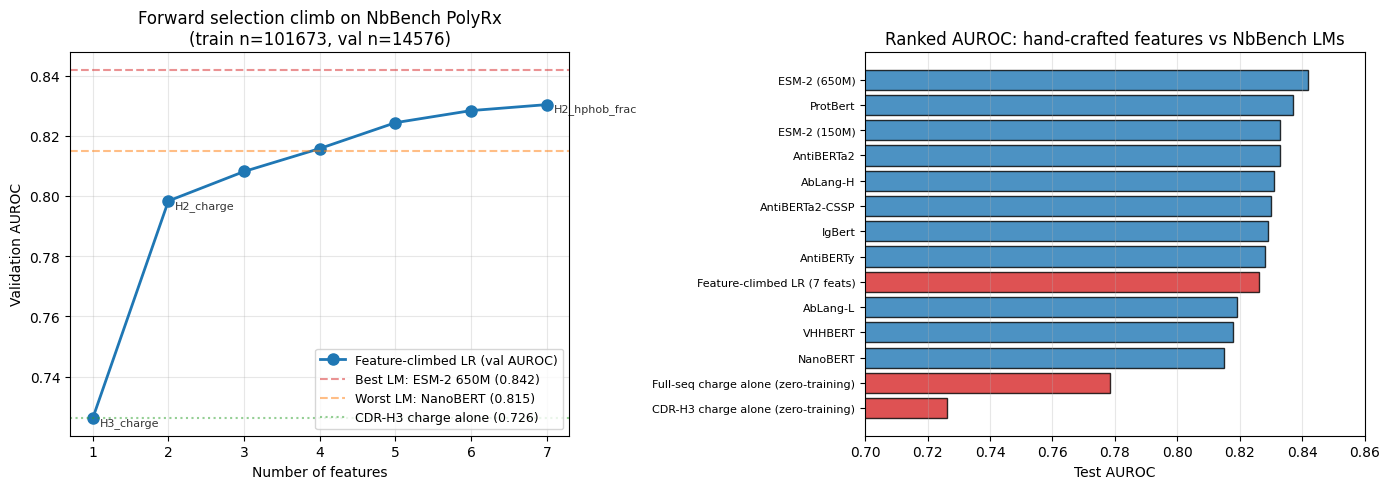

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: AUROC climb curve
ax = axes[0]
ax.plot(climb_df['n_features'], climb_df['val_AUROC'], 'o-', linewidth=2, markersize=8,
         color='#1f77b4', label='Feature-climbed LR (val AUROC)')

# Reference lines for LM performance
ax.axhline(0.842, color='#d62728', linestyle='--', alpha=0.5, label='Best LM: ESM-2 650M (0.842)')
ax.axhline(0.815, color='#ff7f0e', linestyle='--', alpha=0.5, label='Worst LM: NanoBERT (0.815)')
ax.axhline(0.7262, color='#2ca02c', linestyle=':', alpha=0.5, label='CDR-H3 charge alone (0.726)')

ax.set_xlabel('Number of features')
ax.set_ylabel('Validation AUROC')
ax.set_title(f'Forward selection climb on NbBench PolyRx\n(train n={len(X_train_full)}, val n={len(X_val_full)})')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)

# Annotate added features at key steps
for i, row in climb_df.iterrows():
    if i == 0 or i == len(climb_df) - 1 or row['gain'] > 0.01:
        ax.annotate(row['added_feature'], xy=(row['n_features'], row['val_AUROC']),
                     xytext=(5, -5), textcoords='offset points', fontsize=8, rotation=0,
                     alpha=0.8)

# Right: full comparison bar chart
ax = axes[1]
top_n = 15  # show top 15 models
sub = comparison.head(top_n).iloc[::-1]  # reverse for bottom-up plotting
colors = ['#d62728' if 'charge' in m or 'Feature-climbed' in m else '#1f77b4' for m in sub['model']]
ax.barh(range(len(sub)), sub['AUROC'], color=colors, alpha=0.8, edgecolor='black')
ax.set_yticks(range(len(sub)))
ax.set_yticklabels(sub['model'], fontsize=8)
ax.set_xlim(0.70, 0.86)
ax.set_xlabel('Test AUROC')
ax.set_title(f'Ranked AUROC: hand-crafted features vs NbBench LMs')
ax.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(DRIVE_OUTPUT / 'feature_climb.png', dpi=150, bbox_inches='tight')
plt.show()

## §7. Save summary

In [ ]:
summary = {
    'version': PROJECT_VERSION,
    'dataset': 'ZYMScott/polyreaction (NbBench PolyRx)',
    'train_n': int(len(X_train_full)),
    'val_n': int(len(X_val_full)),
    'test_n': int(len(X_test_full)),
    'n_candidate_features': len(feature_names),
    'selected_features_in_order': selected,
    'climb_history': climb_df.to_dict(orient='records'),
    'final_model': {
        'n_features': len(selected),
        'test_AUROC': float(test_auc),
        'test_AUROC_95ci': [float(ci_lo), float(ci_hi)],
        'test_AUPRC': float(test_auprc),
        'coefficients': {feat: float(c) for feat, c in zip(selected, final_lr.coef_[0])},
    },
    'nbbench_lm_range': {'best': 0.842, 'worst': 0.815},
    'gap_to_best_LM': float(0.842 - test_auc),
    'gap_to_worst_LM': float(0.815 - test_auc),
    'LMs_beaten': int(sum(1 for auc in nbbench_table10.values() if auc < test_auc)),
}
with open(DRIVE_OUTPUT / 'summary.json', 'w') as f:
    json.dump(summary, f, indent=2, default=str)

print("Outputs saved to:", DRIVE_OUTPUT)
print()
print("=" * 75)
print("HEADLINE")
print("=" * 75)
print(f"Feature-climbed LR with {len(selected)} hand-crafted features:")
print(f"  Test AUROC = {test_auc:.4f}  95% CI [{ci_lo:.4f}, {ci_hi:.4f}]")
print(f"  Starting from charge alone: 0.7262  ->  final: {test_auc:.4f}  (gain {test_auc - 0.7262:+.4f})")
print(f"  Gap to best LM (ESM-2 650M @ 0.842): {0.842 - test_auc:+.4f}")
print(f"  LMs beaten: {sum(1 for auc in nbbench_table10.values() if auc < test_auc)}/11")

Outputs saved to: /content/drive/MyDrive/PolyAtlas/PolyAtlas_05f_feature_climb_v0.1.0

HEADLINE
Feature-climbed LR with 7 hand-crafted features:
  Test AUROC = 0.8263  95% CI [0.8208, 0.8317]
  Starting from charge alone: 0.7262  ->  final: 0.8263  (gain +0.1001)
  Gap to best LM (ESM-2 650M @ 0.842): +0.0157
  LMs beaten: 3/11
